# Imports and data/model preparation

In [1]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, PROJ_ROOT
from script.trainer import Trainer, EarlyStopping
from models.SwinTransformer import SwinClassifier
import torch
import torch.nn as nn
import torchmetrics.classification as metrics
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

2025-08-07 21:20:48.865 | INFO     | config:<module>:12 - PROJ_ROOT path is: /home/aislab/princisgh_map_completeness/map_completeness_estimation


## Visualize study parameters

In [2]:
study_file = PROJ_ROOT / 'studies/SwinClassifier_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [3]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_batch_size,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.048521,2025-08-07 08:36:09.119500,2025-08-07 09:01:40.820645,0 days 00:25:31.701145,0.000053,32,0.0,0.000018,128,NaN,1,0.162547,0.043118,0.046871,COMPLETE
3,3,0.441425,2025-08-07 09:13:08.295879,2025-08-07 09:39:52.259877,0 days 00:26:43.963998,0.000317,16,0.1,0.009962,256,1024.0,2,0.099569,0.441425,NaN,COMPLETE
4,4,0.043469,2025-08-07 09:39:52.952430,2025-08-07 10:06:51.052523,0 days 00:26:58.100093,0.000003,16,0.0,0.002422,2048,NaN,1,0.000289,0.043087,NaN,COMPLETE
13,13,0.063891,2025-08-07 11:26:07.414578,2025-08-07 11:50:20.769791,0 days 00:24:13.355213,0.000018,64,0.0,0.000412,256,NaN,1,0.000077,0.045894,0.042253,COMPLETE
25,25,0.056293,2025-08-07 14:04:50.907602,2025-08-07 14:30:22.925957,0 days 00:25:32.018355,0.000008,32,0.0,0.000174,256,NaN,1,0.000519,0.041331,NaN,COMPLETE


In [4]:
params = study.best_params
print(params)

{'backbone_LR': 2.77388140215849e-06, 'head_LR': 0.0024219966477544725, 'weight_decay': 0.0002890716668205476, 'batch_size': 16, 'head_layer_1': 2048, 'num_layers': 1, 'dropout': 0.0}


In [5]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [6]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [7]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='classification', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='classification', )
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='classification', )

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'], num_workers=8)
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8)

In [8]:
head_cfg = {
    'hidden_dims' : [2048],
    'dropout_rate': params['dropout']
}
model = SwinClassifier(img_size=224, head_cfg=head_cfg)

loss = torch.nn.CrossEntropyLoss()
ES = EarlyStopping(patience=5, restore_best_weights=True)
met = {
    "accuracy": metrics.BinaryAccuracy(),
    "precision": metrics.BinaryPrecision(),
    "recall": metrics.BinaryRecall(),
}

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 20

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss, met)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

### Compute CV loss

In [9]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=params['batch_size'], 
    task="classification", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/721 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/181 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/721 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/181 [00:00<?, ?it/s]

...


Epoch 14/15:   0%|          | 0/721 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/181 [00:00<?, ?it/s]


Epoch 15/15:   0%|          | 0/721 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/181 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.1268
5-fold CV loss: 0.1475
k-Fold CV loss: 0.14754


## Train classifier

In [10]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'classification', epochs=EPOCHS, early_stopping=ES)


Epoch 1/20:   0%|          | 0/901 [00:00<?, ?it/s]

[1/20] Train Loss: 0.2317


Evaluation:   0%|          | 0/207 [00:00<?, ?it/s]

	accuracy: 0.9449
	precision: 0.9450
	recall: 0.9447
[1/20] Val Loss: 0.1792 



Epoch 2/20:   0%|          | 0/901 [00:00<?, ?it/s]

...

	accuracy: 0.9478
	precision: 0.9497
	recall: 0.9457
[10/20] Val Loss: 0.1603 



Epoch 11/20:   0%|          | 0/901 [00:00<?, ?it/s]

[11/20] Train Loss: 0.1248


Evaluation:   0%|          | 0/207 [00:00<?, ?it/s]

	accuracy: 0.9476
	precision: 0.9505
	recall: 0.9444
[11/20] Val Loss: 0.1425 
Stopping training due to EarlyStopping


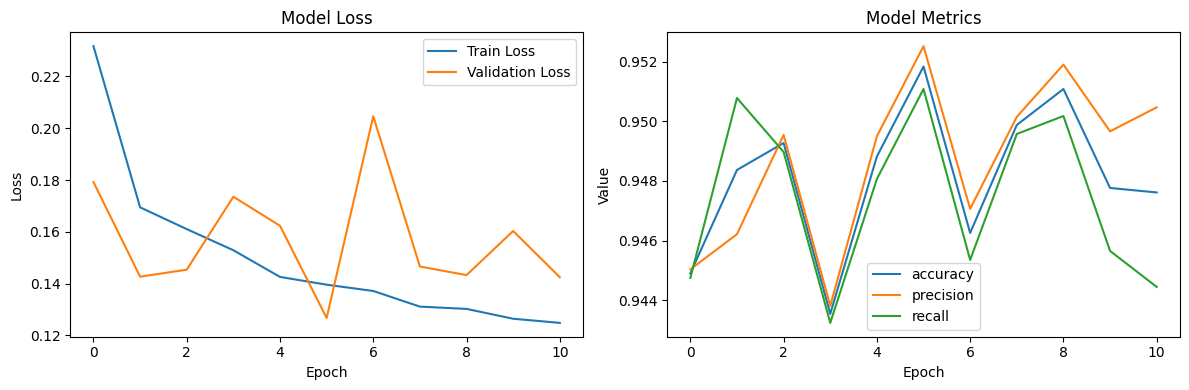

In [11]:
plot_history(trainer.history)

#### Validation Results

In [12]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR)

Evaluation:   0%|          | 0/207 [00:00<?, ?it/s]

	accuracy: 0.9518
	precision: 0.9525
	recall: 0.9511
Model SwinClassifier_classification.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [13]:
y_hat, y_true, test_loss = trainer.predict(test_loader)
print(f'Test Loss: {test_loss}')

Evaluation:   0%|          | 0/189 [00:00<?, ?it/s]

Test Loss: 0.20067256779247333


In [14]:
import torch.nn as nn
y_hat_np = nn.Softmax()(y_hat)[:,0].numpy()
y_true_np = y_true[:,0].numpy()

/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1751: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



In [15]:
def print_metrics(y_hat: np.ndarray, y_true: np.ndarray):
    print(classification_report(y_true, y_hat))
    print(f'Accuracy: {accuracy_score(y_true, y_hat)}')
    print(f'Precision: {precision_score(y_true, y_hat)}')
    print(f'Recall: {recall_score(y_true, y_hat)}')

    # confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_hat)
    #print cm values with labels
    cm_df = pd.DataFrame(cm, index=['Not Explored', 'Explored'], columns=['Not Explored', 'Explored'])
    print("Confusion Matrix DataFrame:")
    print(cm_df)

### Classification metrics for $\theta = 0.5$

In [16]:
y_hat_theta = (y_hat_np > 0.5).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91      1377
         1.0       0.94      0.90      0.92      1632

    accuracy                           0.92      3009
   macro avg       0.91      0.92      0.92      3009
weighted avg       0.92      0.92      0.92      3009

Accuracy: 0.9159189099368561
Precision: 0.9422706863373957
Recall: 0.9001225490196079
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1287        90
Explored               163      1469


### Classification metrics for $\theta = 0.8$

In [17]:
y_hat_theta = (y_hat_np > 0.8).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.81      0.97      0.88      1377
         1.0       0.97      0.81      0.88      1632

    accuracy                           0.88      3009
   macro avg       0.89      0.89      0.88      3009
weighted avg       0.90      0.88      0.88      3009

Accuracy: 0.8820206048521103
Precision: 0.9691403379867745
Recall: 0.8082107843137255
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1335        42
Explored               313      1319


### Visualize ROC & AUROC

In [9]:
head_cfg = {
    'hidden_dims' : [2048],
    'dropout_rate': 0.0
}
model = SwinClassifier(224, head_cfg)

model.load_state_dict(torch.load(MODELS_DIR / 'SwinClassifier_classification.pt'))
model.eval()
trainer.model = model.to('cuda')

y_hat, y_true, test_loss = trainer.predict(test_loader)
print(f'Test Loss: {test_loss}')
import torch.nn as nn
y_hat_np = nn.Softmax()(y_hat)[:,0].numpy()
y_true_np = y_true[:,0].numpy()

Evaluation:   0%|          | 0/189 [00:00<?, ?it/s]

Test Loss: 0.2006710718950089


/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1751: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



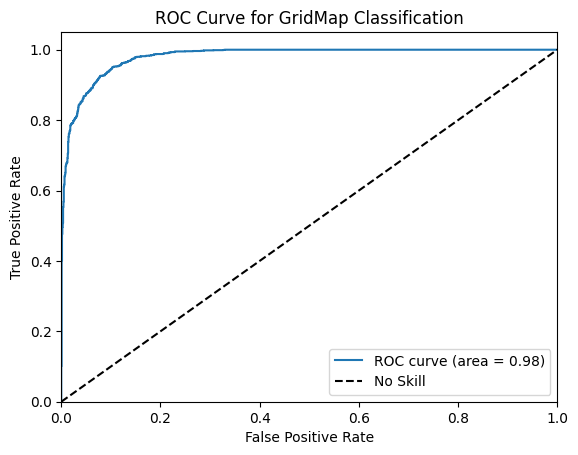

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true_np, y_hat_np)
roc_auc = auc(fpr, tpr)

plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for GridMap Classification')
plt.legend()
plt.show()